In [1]:
!pip install rasterio geopandas numpy scikit-learn pandas matplotlib


Defaulting to user installation because normal site-packages is not writeable


In [1]:
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
from rasterio.mask import mask
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


In [2]:
# Open the raster file
raster_path = "/scratch/ope4/POLY_2/POLY_2/MERGED_RASTER/SENT_MERGED.tif"  # Replace with your file path
with rasterio.open(raster_path) as src:
    raster_data = src.read()  # Read all bands (includes class labels)
    profile = src.profile  # Save metadata


In [3]:
import rasterio


# Open the raster dataset
with rasterio.open('/scratch/ope4/POLY_2/POLY_2/MERGED_RASTER/SENT_MERGED.tif') as src:
    # Get the number of bands
    num_bands = src.count
    print(f"Number of bands: {num_bands}")

    # Iterate through the bands and print their information
    for i in range(1, num_bands + 1):
        band = src.read(i)
        print(f"Band {i}:")
        print(f"  Shape: {band.shape}")
        print(f"  Minimum value: {band.min()}")
        print(f"  Maximum value: {band.max()}")
        print(f"  Data type: {band.dtype}")

Number of bands: 14
Band 1:
  Shape: (24, 134)
  Minimum value: 0.0
  Maximum value: 15.0
  Data type: float32
Band 2:
  Shape: (24, 134)
  Minimum value: 0.0
  Maximum value: 15.0
  Data type: float32
Band 3:
  Shape: (24, 134)
  Minimum value: -3.4028234663852886e+38
  Maximum value: 669.0
  Data type: float32
Band 4:
  Shape: (24, 134)
  Minimum value: -3.4028234663852886e+38
  Maximum value: 1528.0
  Data type: float32
Band 5:
  Shape: (24, 134)
  Minimum value: -3.4028234663852886e+38
  Maximum value: 2024.0
  Data type: float32
Band 6:
  Shape: (24, 134)
  Minimum value: -3.4028234663852886e+38
  Maximum value: 2423.0
  Data type: float32
Band 7:
  Shape: (24, 134)
  Minimum value: -3.4028234663852886e+38
  Maximum value: 2794.5
  Data type: float32
Band 8:
  Shape: (24, 134)
  Minimum value: -3.4028234663852886e+38
  Maximum value: 5314.0
  Data type: float32
Band 9:
  Shape: (24, 134)
  Minimum value: -3.4028234663852886e+38
  Maximum value: 6332.5
  Data type: float32
Band 10:

              precision    recall  f1-score   support

         1.0       0.46      0.24      0.31        55
         3.0       0.89      0.96      0.92       364

    accuracy                           0.86       419
   macro avg       0.68      0.60      0.62       419
weighted avg       0.84      0.86      0.84       419



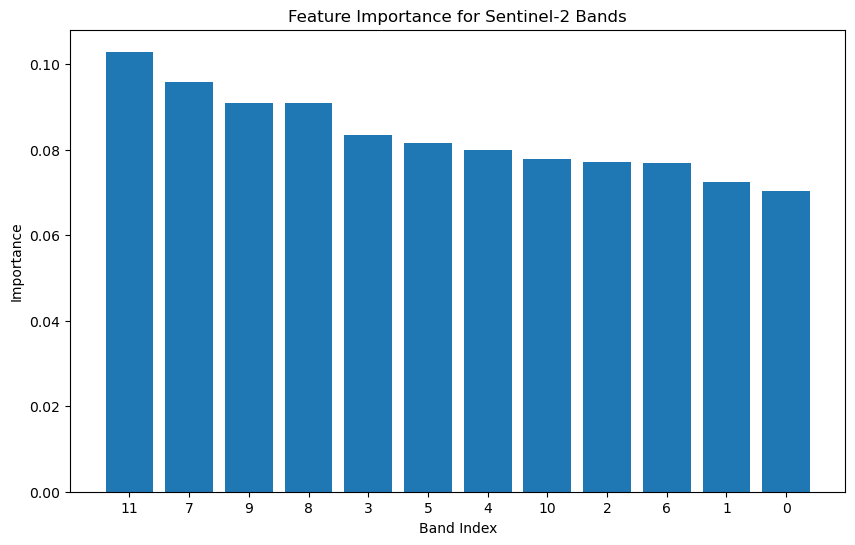

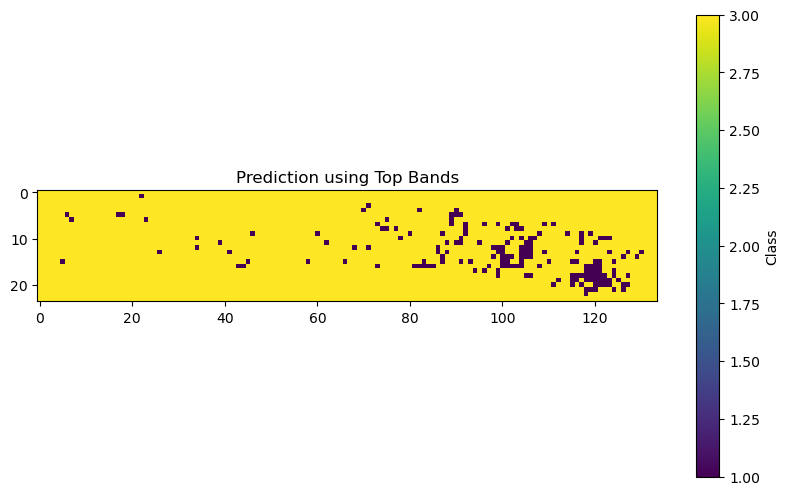

In [7]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Open the raster file
#
with rasterio.open('/scratch/ope4/POLY_2/POLY_2/MERGED_RASTER/SENT_MERGED.tif') as src:
    # Read all bands as a 3D array (bands, height, width)
    bands = src.read()
    
    # Get the width and height of the raster (which will be needed for reshaping)
    height = src.height
    width = src.width
    
# Extract the first two bands as class labels
class_labels = bands[(0)]  # Assuming the first two bands are classes

# Extract the remaining bands as features
features = bands[2:]  # Sentinel-2 bands are in the remaining bands

# Reshape the arrays to create a 2D dataset (samples, features)
X = np.stack([features[i].flatten() for i in range(features.shape[0])], axis=-1)

# Flatten the class labels as well
y = class_labels.flatten()

# Remove samples where the label equals 15
mask  = ~np.isin(y, [15, 0, 2, 4, 2147483647])
X = X[mask]
y = y[mask]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Evaluate the model
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Get feature importances from the trained model
importances = rf.feature_importances_

# Sort the feature importances in descending order
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Sentinel-2 Bands")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), indices)
plt.xlabel("Band Index")
plt.ylabel("Importance")
plt.show()

# Select the top 3 most important bands (for example)
top_bands_indices = indices[:3]
top_bands = features[top_bands_indices]

# Reshape the top bands into the correct format for prediction
X_top = np.stack([top_bands[i].flatten() for i in range(len(top_bands))], axis=-1)

# Train a new model using only the top bands
rf_top = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top.fit(X_train[:, top_bands_indices], y_train)

# Predict using the model trained on the top bands
full_pred_top = rf_top.predict(X_top)

# Reshape the predictions back into the original image shape (height, width)
pred_raster_top = full_pred_top.reshape(height, width)

# You can then save the prediction back to a raster file (optional)
with rasterio.open('predicted_classification_top_bands.tif', 'w', **src.meta) as dst:
    dst.write(pred_raster_top, 1)

# Plot the predicted classification for top bands
plt.figure(figsize=(10, 6))
plt.imshow(pred_raster_top, cmap='viridis')
plt.colorbar(label='Class')
plt.title("Prediction using Top Bands")
plt.show()


In [12]:
# Update metadata for saving
meta = src.meta.copy()
meta.update(count=1, dtype=pred_raster_top.dtype)

# Save the classified raster
with rasterio.open('predicted_classification_top_bands.tif', 'w', **meta) as dst:
    dst.write(pred_raster_top, 1)  # Writing a single band


In [8]:
# Train the model with the top bands
rf_top = RandomForestClassifier(n_estimators=100, random_state=42)
rf_top.fit(X_train[:, top_bands_indices], y_train)

# Predict on X_test (not X_top)
full_pred_top = rf_top.predict(X_test[:, top_bands_indices])

# Evaluate the model
print(classification_report(y_test, full_pred_top))


              precision    recall  f1-score   support

         1.0       0.47      0.25      0.33        55
         3.0       0.89      0.96      0.92       364

    accuracy                           0.86       419
   macro avg       0.68      0.61      0.63       419
weighted avg       0.84      0.86      0.85       419



In [9]:
print(top_bands_indices)

[11  7  9]


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Full model:', cm)

Full model: [[ 13  42]
 [ 15 349]]


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
# Create the confusion matrix
cm = confusion_matrix(y_test, full_pred_top)
print('Simpler model:', cm)

Simpler model: [[ 14  41]
 [ 16 348]]
